"""
End-to-End Fraud Detection Pipeline
"""
=====================================
This pipeline covers:


# Import Library

In [ ]:
import numpy as np
import pandas as pd
import gdown
import gc
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

import lightgbm as lgb
import matplotlib.pyplot as plt

print("✅ Libraries imported!")

✅ Libraries imported!


# Memory Optimization

In [ ]:
def reduce_mem_usage(df, verbose=True):
    """Aggressively reduce memory usage"""
    start_mem = df.memory_usage().sum() / 1024**2

    for col in df.columns:
        col_type = df[col].dtype

        if col_type != object:
            c_min, c_max = df[col].min(), df[col].max()

            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)

    end_mem = df.memory_usage().sum() / 1024**2
    if verbose:
        print(f'Memory: {start_mem:.1f}MB → {end_mem:.1f}MB ({100*(start_mem-end_mem)/start_mem:.1f}% reduction)')

    return df

# Load Data

In [ ]:
# Download files
train_url = 'https://drive.google.com/uc?id=1vA9rGGPElhn7rARS1qJyIAUJDny36mhy'
test_url = 'https://drive.google.com/uc?id=182S6yNqDfluSw6FIvya5ZGD-3ia963Lx'

gdown.download(train_url, 'train_transaction.csv', quiet=False)
gdown.download(test_url, 'test_transaction.csv', quiet=False)

# Define columns to use (drop high-missing and less useful columns)
# V columns with >50% missing will be dropped
use_cols_train = ['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt',
                  'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6',
                  'addr1', 'addr2', 'dist1', 'P_emaildomain', 'R_emaildomain',
                  'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14',
                  'D1', 'D2', 'D3', 'D4', 'D5', 'D10', 'D11', 'D15',
                  'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
                  'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
                  'V29', 'V30', 'V31', 'V32', 'V33', 'V34', 'V35', 'V36', 'V37', 'V38',
                  'V44', 'V45', 'V46', 'V47', 'V48', 'V49', 'V50', 'V51', 'V52', 'V53', 'V54',
                  'V69', 'V70', 'V71', 'V72', 'V73', 'V74', 'V75', 'V76', 'V77', 'V78',
                  'V279', 'V280', 'V281', 'V282', 'V283', 'V284', 'V285', 'V286', 'V287',
                  'V294', 'V295', 'V296', 'V297', 'V298', 'V299', 'V300', 'V301', 'V302', 'V303', 'V304',
                  'V306', 'V307', 'V308', 'V309', 'V310', 'V311', 'V312', 'V313', 'V314', 'V315', 'V316', 'V317', 'V318', 'V319', 'V320', 'V321']

use_cols_test = [c for c in use_cols_train if c != 'isFraud']

# Load only selected columns
print("\n📂 Loading train data...")
train = pd.read_csv('train_transaction.csv', usecols=use_cols_train)
train = reduce_mem_usage(train)
gc.collect()

print("\n📂 Loading test data...")
test = pd.read_csv('test_transaction.csv', usecols=use_cols_test)
test = reduce_mem_usage(test)
gc.collect()

print(f"\n✅ Train shape: {train.shape}")
print(f"✅ Test shape: {test.shape}")
print(f"✅ Fraud rate: {train['isFraud'].mean()*100:.2f}%")

# Store test IDs
test_ids = test['TransactionID'].values.copy()

Downloading...
From (original): https://drive.google.com/uc?id=1vA9rGGPElhn7rARS1qJyIAUJDny36mhy
From (redirected): https://drive.google.com/uc?id=1vA9rGGPElhn7rARS1qJyIAUJDny36mhy&confirm=t&uuid=1fa4b087-2a6a-43ec-94b8-09e3a443f841
To: /content/train_transaction.csv
100%|██████████| 683M/683M [00:03<00:00, 200MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=182S6yNqDfluSw6FIvya5ZGD-3ia963Lx
From (redirected): https://drive.google.com/uc?id=182S6yNqDfluSw6FIvya5ZGD-3ia963Lx&confirm=t&uuid=0e53fbf0-2d89-4a57-88d6-2d47dd77deb4
To: /content/test_transaction.csv
100%|██████████| 613M/613M [00:07<00:00, 83.9MB/s]



📂 Loading train data...
Memory: 563.2MB → 169.5MB (69.9% reduction)

📂 Loading test data...
Memory: 479.4MB → 146.9MB (69.4% reduction)

✅ Train shape: (590540, 125)
✅ Test shape: (506691, 124)
✅ Fraud rate: 3.50%


# EXPLORATORY DATA ANALYSIS


📊 Target Distribution:
isFraud
0    569877
1     20663
Name: count, dtype: int64

📊 Missing Values (Top 10):
R_emaildomain    76.751617
dist1            59.652352
D5               52.467403
D2               47.549192
V9               47.293494
V1               47.293494
V2               47.293494
V3               47.293494
V4               47.293494
V6               47.293494
dtype: float64


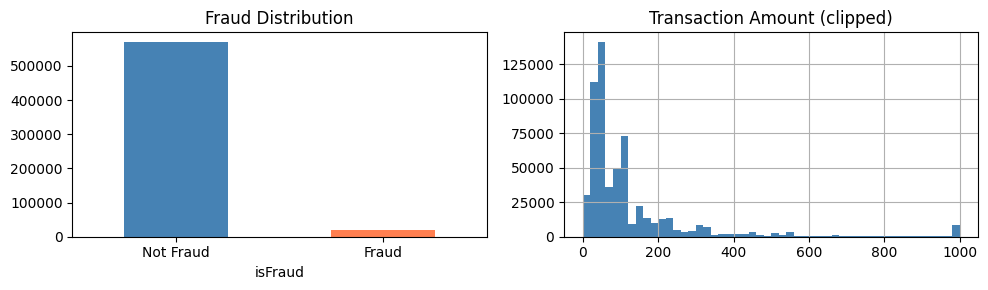

In [ ]:
print(f"\n📊 Target Distribution:")
print(train['isFraud'].value_counts())
print(f"\n📊 Missing Values (Top 10):")
missing = (train.isnull().sum() / len(train) * 100).sort_values(ascending=False)
print(missing.head(10))

# Simple visualization
fig, ax = plt.subplots(1, 2, figsize=(10, 3))
train['isFraud'].value_counts().plot(kind='bar', ax=ax[0], color=['steelblue', 'coral'])
ax[0].set_title('Fraud Distribution')
ax[0].set_xticklabels(['Not Fraud', 'Fraud'], rotation=0)
train['TransactionAmt'].clip(upper=1000).hist(bins=50, ax=ax[1], color='steelblue')
ax[1].set_title('Transaction Amount (clipped)')
plt.tight_layout()
plt.show()

# FEATURE ENGINEERING

In [ ]:
def add_features(df):
    """Add minimal but effective features"""
    # Time features
    df['hour'] = ((df['TransactionDT'] // 3600) % 24).astype(np.int8)
    df['day'] = ((df['TransactionDT'] // (3600*24)) % 7).astype(np.int8)

    # Amount features
    df['amt_log'] = np.log1p(df['TransactionAmt']).astype(np.float16)
    df['amt_decimal'] = (df['TransactionAmt'] - df['TransactionAmt'].astype(int)).astype(np.float16)

    # Drop original TransactionDT to save memory
    df.drop('TransactionDT', axis=1, inplace=True)

    return df

train = add_features(train)
test = add_features(test)
gc.collect()

print(f"✅ Train shape after features: {train.shape}")

✅ Train shape after features: (590540, 128)


# DATA PREPROCESSING

In [ ]:
# Separate target
y = train['isFraud'].values
train.drop(['isFraud', 'TransactionID'], axis=1, inplace=True)
test.drop('TransactionID', axis=1, inplace=True)
gc.collect()

# Get column lists
cat_cols = train.select_dtypes(include=['object']).columns.tolist()
num_cols = train.select_dtypes(include=[np.number]).columns.tolist()

print(f"📊 Categorical columns: {len(cat_cols)}")
print(f"📊 Numerical columns: {len(num_cols)}")

# Fill missing - numerical with -999, categorical with 'missing'
print("\n🔄 Filling missing values...")
for col in num_cols:
    train[col].fillna(-999, inplace=True)
    test[col].fillna(-999, inplace=True)

# Encode categoricals
print("🔄 Encoding categoricals...")
for col in cat_cols:
    train[col] = train[col].fillna('missing').astype(str)
    test[col] = test[col].fillna('missing').astype(str)

    le = LabelEncoder()
    le.fit(pd.concat([train[col], test[col]]))
    train[col] = le.transform(train[col]).astype(np.int16)
    test[col] = le.transform(test[col]).astype(np.int16)

gc.collect()

# Reduce memory again after preprocessing
train = reduce_mem_usage(train, verbose=False)
test = reduce_mem_usage(test, verbose=False)
gc.collect()

print(f"✅ Final train shape: {train.shape}")
print(f"✅ Final test shape: {test.shape}")

📊 Categorical columns: 5
📊 Numerical columns: 121

🔄 Filling missing values...
🔄 Encoding categoricals...
✅ Final train shape: (590540, 126)
✅ Final test shape: (506691, 126)


# Train/Validation Split

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    train.values, y, test_size=0.2, random_state=42, stratify=y
)

# Store feature names before converting
feature_names = train.columns.tolist()

# Convert test to numpy and free DataFrame
X_test = test.values
del train, test
gc.collect()

print(f"✅ X_train: {X_train.shape}")
print(f"✅ X_val: {X_val.shape}")
print(f"✅ X_test: {X_test.shape}")

✅ X_train: (472432, 126)
✅ X_val: (118108, 126)
✅ X_test: (506691, 126)


Train LightGBM

In [ ]:
# Calculate scale_pos_weight
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
print(f"📊 Scale pos weight: {scale_pos:.2f}")

# LightGBM parameters - optimized for memory
lgb_params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'num_leaves': 64,
    'learning_rate': 0.05,
    'feature_fraction': 0.7,
    'bagging_fraction': 0.7,
    'bagging_freq': 5,
    'max_depth': 8,
    'min_child_samples': 100,
    'reg_alpha': 0.1,
    'reg_lambda': 0.1,
    'scale_pos_weight': scale_pos,
    'verbose': -1,
    'random_state': 42,
    'n_jobs': -1,
    'max_bin': 63  # Reduce memory
}

# Create datasets
train_data = lgb.Dataset(X_train, label=y_train, feature_name=feature_names, free_raw_data=True)
val_data = lgb.Dataset(X_val, label=y_val, reference=train_data, free_raw_data=True)

# Train
print("\n🚀 Training...")
model = lgb.train(
    lgb_params,
    train_data,
    num_boost_round=1000,
    valid_sets=[train_data, val_data],
    valid_names=['train', 'valid'],
    callbacks=[
        lgb.early_stopping(100),
        lgb.log_evaluation(200)
    ]
)

print(f"\n✅ Best iteration: {model.best_iteration}")

# Free training data
del train_data, val_data, X_train
gc.collect()

📊 Scale pos weight: 27.58

🚀 Training...
Training until validation scores don't improve for 100 rounds
[200]	train's auc: 0.955013	valid's auc: 0.935779
[400]	train's auc: 0.973372	valid's auc: 0.947573
[600]	train's auc: 0.982832	valid's auc: 0.9534
[800]	train's auc: 0.988342	valid's auc: 0.956814
[1000]	train's auc: 0.991833	valid's auc: 0.958845
Did not meet early stopping. Best iteration is:
[1000]	train's auc: 0.991833	valid's auc: 0.958845

✅ Best iteration: 1000


259

# MODEL EVALUATION


📈 ROC-AUC Score: 0.9588

📋 Classification Report:
              precision    recall  f1-score   support

   Not Fraud       0.99      0.95      0.97    113975
       Fraud       0.38      0.83      0.52      4133

    accuracy                           0.95    118108
   macro avg       0.68      0.89      0.74    118108
weighted avg       0.97      0.95      0.96    118108


📋 Confusion Matrix:
[[108274   5701]
 [   701   3432]]


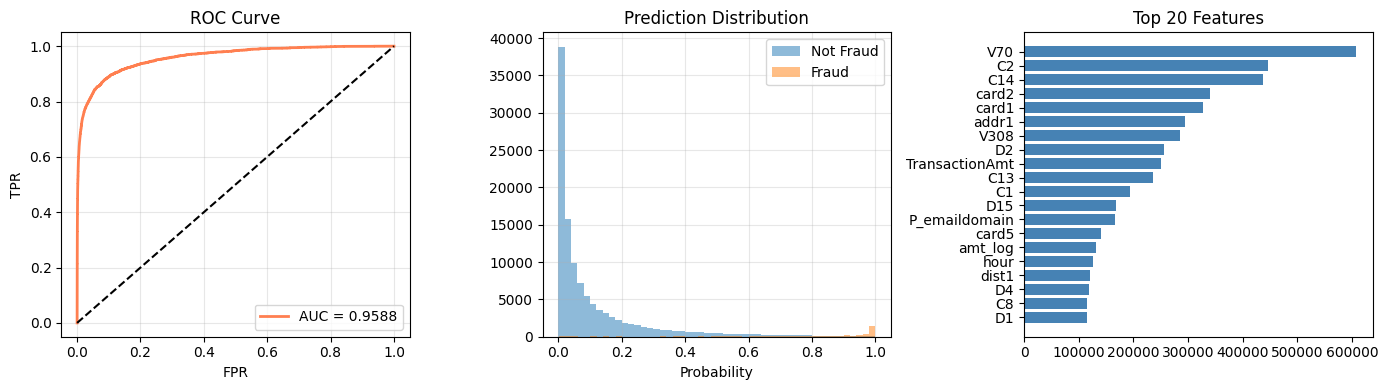

3

In [ ]:
# Predict on validation
y_pred_proba = model.predict(X_val)
y_pred = (y_pred_proba > 0.5).astype(int)

# Metrics
roc_auc = roc_auc_score(y_val, y_pred_proba)
print(f"\n📈 ROC-AUC Score: {roc_auc:.4f}")
print("\n📋 Classification Report:")
print(classification_report(y_val, y_pred, target_names=['Not Fraud', 'Fraud']))

# Confusion Matrix
cm = confusion_matrix(y_val, y_pred)
print("\n📋 Confusion Matrix:")
print(cm)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# ROC Curve
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(y_val, y_pred_proba)
axes[0].plot(fpr, tpr, color='coral', lw=2, label=f'AUC = {roc_auc:.4f}')
axes[0].plot([0, 1], [0, 1], 'k--')
axes[0].set_title('ROC Curve')
axes[0].set_xlabel('FPR')
axes[0].set_ylabel('TPR')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Prediction Distribution
axes[1].hist(y_pred_proba[y_val==0], bins=50, alpha=0.5, label='Not Fraud')
axes[1].hist(y_pred_proba[y_val==1], bins=50, alpha=0.5, label='Fraud')
axes[1].set_title('Prediction Distribution')
axes[1].set_xlabel('Probability')
axes[1].legend()
axes[1].grid(alpha=0.3)

# Feature Importance (Top 20)
importance = pd.DataFrame({
    'feature': feature_names,
    'importance': model.feature_importance(importance_type='gain')
}).nlargest(20, 'importance')

axes[2].barh(range(len(importance)), importance['importance'].values, color='steelblue')
axes[2].set_yticks(range(len(importance)))
axes[2].set_yticklabels(importance['feature'].values)
axes[2].set_title('Top 20 Features')
axes[2].invert_yaxis()

plt.tight_layout()
plt.savefig('evaluation.png', dpi=100)
plt.show()

# Free validation data
del X_val, y_val, y_pred_proba, y_pred
gc.collect()


# GENERATE SUBMISSION

In [ ]:
# Predict on test
test_pred = model.predict(X_test)

# Create submission
submission = pd.DataFrame({
    'TransactionID': test_ids,
    'isFraud': test_pred
})

submission.to_csv('submission.csv', index=False)
print(f"\n✅ Submission saved!")
print(f"📊 Shape: {submission.shape}")
print(submission.head())


✅ Submission saved!
📊 Shape: (506691, 2)
   TransactionID   isFraud
0        3663549  0.017800
1        3663550  0.001721
2        3663551  0.005540
3        3663552  0.006699
4        3663553  0.024485


# Fraud Table


📊 SUMMARY:
   Total test: 506,691
   Predicted Fraud: 33,535 (6.62%)
   Threshold: 0.5

📋 TOP 30 FRAUD TRANSACTIONS:
 TransactionID  fraud_probability
       3974164           0.999954
       3974293           0.999932
       3974129           0.999927
       3974128           0.999920
       3974245           0.999918
       3966204           0.999910
       3974294           0.999905
       3974284           0.999900
       3974271           0.999892
       3974266           0.999891
       3974174           0.999890
       3966199           0.999884
       3970439           0.999884
       3974221           0.999884
       3974171           0.999874
       3966196           0.999874
       3974146           0.999872
       3862670           0.999871
       3688816           0.999869
       3970120           0.999864
       3845382           0.999863
       3974235           0.999861
       3698416           0.999860
       3862668           0.999860
       3962091           0.99985

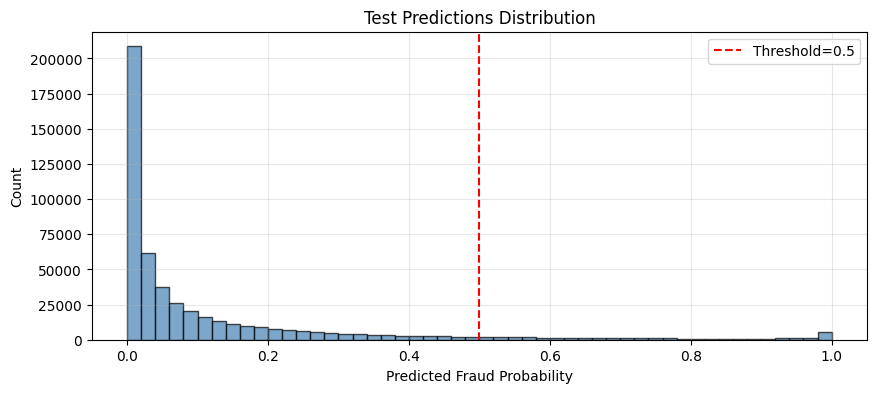


🎉 PIPELINE COMPLETE!

📈 Validation ROC-AUC: 0.9588
📁 Files: submission.csv, fraud_transactions.csv, evaluation.png


In [ ]:
THRESHOLD = 0.5

# Create fraud summary
fraud_mask = test_pred >= THRESHOLD
n_fraud = fraud_mask.sum()

print(f"\n📊 SUMMARY:")
print(f"   Total test: {len(test_pred):,}")
print(f"   Predicted Fraud: {n_fraud:,} ({n_fraud/len(test_pred)*100:.2f}%)")
print(f"   Threshold: {THRESHOLD}")

# Fraud table
fraud_df = pd.DataFrame({
    'TransactionID': test_ids[fraud_mask],
    'fraud_probability': test_pred[fraud_mask]
}).sort_values('fraud_probability', ascending=False)

print(f"\n📋 TOP 30 FRAUD TRANSACTIONS:")
print("="*50)
print(fraud_df.head(30).to_string(index=False))

# High confidence fraud
high_conf = (test_pred >= 0.9).sum()
print(f"\n🚨 HIGH CONFIDENCE FRAUD (>=90%): {high_conf:,}")

# Save fraud table
fraud_df.to_csv('fraud_transactions.csv', index=False)
print(f"\n✅ Fraud table saved to 'fraud_transactions.csv'")

# Visualization
plt.figure(figsize=(10, 4))
plt.hist(test_pred, bins=50, color='steelblue', alpha=0.7, edgecolor='black')
plt.axvline(x=THRESHOLD, color='red', linestyle='--', label=f'Threshold={THRESHOLD}')
plt.xlabel('Predicted Fraud Probability')
plt.ylabel('Count')
plt.title('Test Predictions Distribution')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('test_distribution.png', dpi=100)
plt.show()

print("\n" + "="*50)
print("🎉 PIPELINE COMPLETE!")
print("="*50)
print(f"\n📈 Validation ROC-AUC: {roc_auc:.4f}")
print(f"📁 Files: submission.csv, fraud_transactions.csv, evaluation.png")